# Writing your own Neural Network code

In [1]:
import autograd.numpy as np
import pandas as pd

# custom imports
from runge_preprocessing import x, x_train, x_train_scaled, x_test, y, y_noise, y_train, y_test, layer_dim, activations, activations_derivative, ETA_VALUES, LAMBDA_VALUES, MOMENTUM, RUNGE_MAX_ITERATIONS
from neural_network import NN
import schedulers


In [6]:
# TESTING BLOCK  --- delete later


runge_NN = NN(dims = layer_dim, activation_funcs = activations, activation_ders = activations_derivative)

# Defining optimizers
adam_optimizer = schedulers.ADAM(eta=0.001, rho=0.001, rho2=0.001)
sgd_optimizer = schedulers.momentum(eta=0.001,momentum=0.9)
rmsprop_optimizer = schedulers.RMSprop(eta=0.001,rho=0.1)

# Training and validation
scores, predictions = runge_NN.fit(X=x_train_scaled, t=y_train, X_val=x_test, t_val=y_test, scheduler=adam_optimizer)


print('LOOPIN OVER ADAM WITH L1 AND L2 NOT CORRECT?')



Using scheduler: ADAM with Eta=0.001
LOOPIN OVER ADAM WITH L1 AND L2 NOT CORRECT?


In [3]:
import time
from cost_functions import mse
mse_formula = mse().cost

runge_NN = NN(dims = layer_dim, activation_funcs = activations, activation_ders = activations_derivative)

def neural_network_loop(etas, lambdas, optimizer_name, max_iterations, momentum_val=0.9, verbose=True):


    results = []

    for eta in etas:
        for lmbd in lambdas:
            
            if verbose:
                print(f"\nTraining with lr={eta}, lambda={lmbd}, iteration={max_iterations}, optimizer={optimizer_name}")

            start_time = time.time()

            if optimizer_name == 'ADAM':
                optimizer = schedulers.ADAM(eta, rho=lmbd, rho2=lmbd)   # both rho and rho1 at same time? different looping...?
            elif optimizer_name == 'SGD':
                optimizer = schedulers.momentum(eta, momentum=momentum_val)
            elif optimizer_name == 'RMSprop':
                optimizer = schedulers.RMSprop(eta=etas,rho=lmbd)

            epoch_scores, predictions = runge_NN.fit(X=x_train_scaled, 
                                                     t=y_train, 
                                                     X_val=x_test, 
                                                     t_val=y_test, 
                                                     epochs=max_iterations, 
                                                     scheduler=optimizer)
            
            final_mse = mse_formula(y_true=y_test, y_pred=predictions)
            
            elapsed_time = time.time() - start_time

            results.append({
                'Learning Rate': eta,
                'Lambda': lmbd,
                'Iterations': max_iterations,
                'Elapsed Time (s)': round(elapsed_time, 2),
                'Training Errors': epoch_scores['training_errors'],
                'Validation Errors': epoch_scores['validation_errors'],
                'Final MSE': final_mse,
                'Predictions': predictions
            })
    return pd.DataFrame(results)

results_sgd = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'SGD', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=False)
results_rmsprop = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'RMSprop', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=False)
results_adam = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'ADAM', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=True) #- optimizer does not work - NOT MOMENTUM



Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.001
Using scheduler: momentum with Eta=0.001
Using scheduler: momentum with Eta=0.001
Using scheduler: momentum with Eta=0.001
Using scheduler: momentum with Eta=0.001
Using

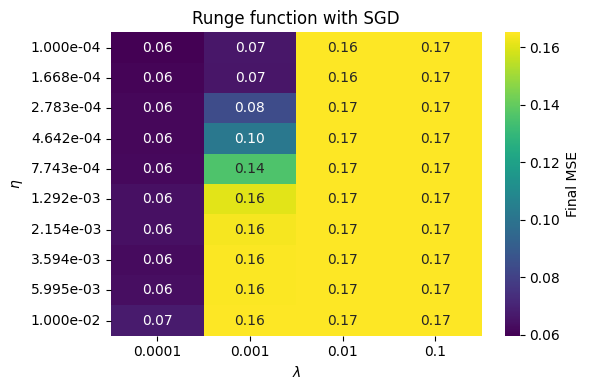

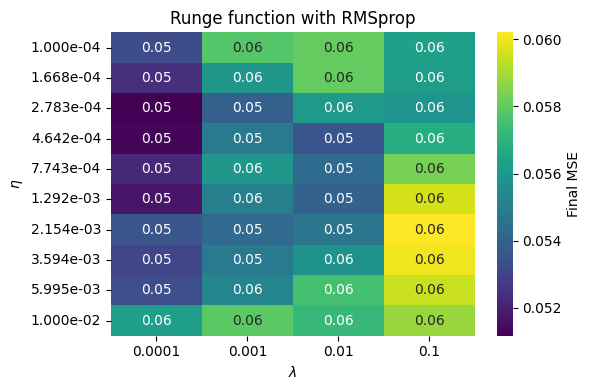

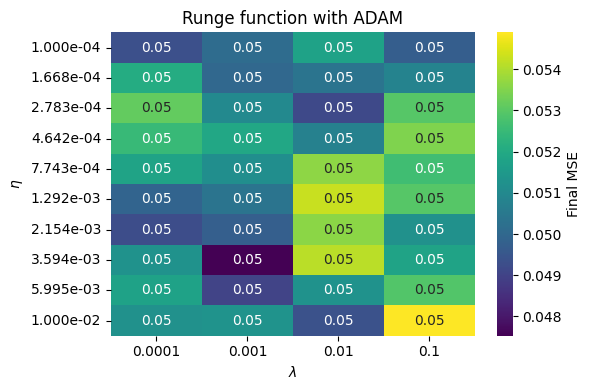

In [4]:
from plotting import plot_heatmap

SHOW_PLOT = True

plot_heatmap(results_sgd, title='Runge function with SGD', heat_metric='Final MSE', filename=f'runge_heatmap_sgd_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}', show_plot=SHOW_PLOT)
plot_heatmap(results_rmsprop, title='Runge function with RMSprop', heat_metric='Final MSE', filename=f'runge_heatmap_rmsprop_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam, title='Runge function with ADAM', heat_metric='Final MSE') 


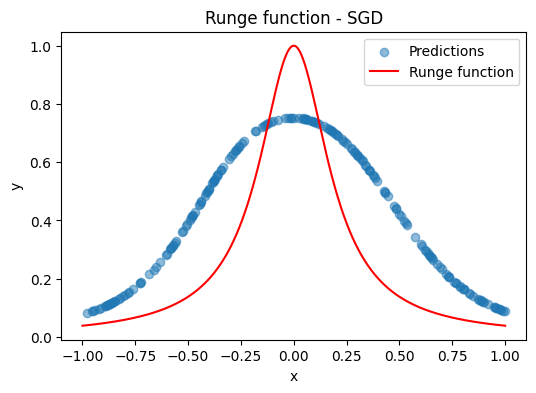

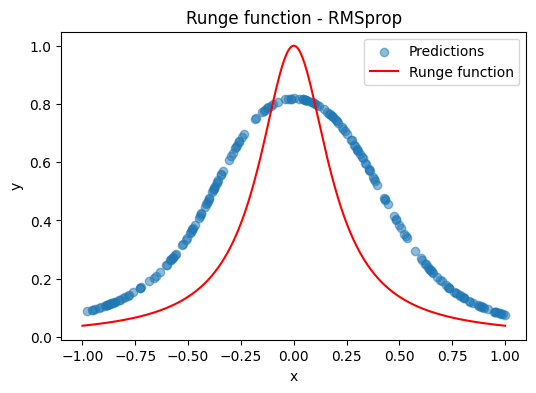

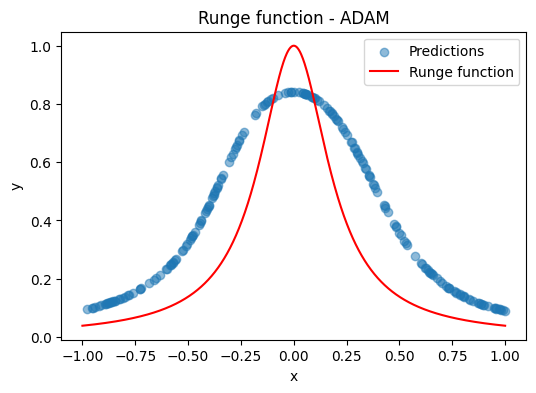

In [5]:
from plotting import plot_runges

SHOW_PLOT = True

# SGD
min_row = results_sgd.loc[results_sgd['Final MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - SGD', filename=f'runge_predicted_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}', show_plot=SHOW_PLOT)

# RMSprop
min_row = results_rmsprop.loc[results_sgd['Final MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - RMSprop', filename=f'runge_predicted_rmsprop_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}', show_plot=SHOW_PLOT)

# ADAM 
min_row = results_adam.loc[results_sgd['Final MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM', filename=f'runge_predicted_adam_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}', show_plot=SHOW_PLOT)